# Preprocessing Part Two: QC/Filtering, Normalization, Dimensionality Reduction

## Load Data

In [ ]:
import os
import numpy as np
import anndata as ad
import scanpy as sc
import matplotlib.pyplot as plt
import harmonypy as hm
import random

input_dir = os.path.join("data")
output_dir = os.path.join("data")

SEED = 7
np.random.seed(SEED)
random.seed(SEED)

In [ ]:
samples = ["PBMC_Control1", "PBMC_Control2", "Lung_Cancer_PBMC"]
adata_dict = {}
for sample in samples:
    sample_adata = ad.read_h5ad(os.path.join(input_dir, sample + ".h5ad"))
    sample_adata.var_names_make_unique()
    adata_dict[sample] = sample_adata
adata = ad.concat(adata_dict, label="sample")
adata.obs_names_make_unique()
# anndataR saved expression data into counts. Copy into X for processing.
adata.X = adata.layers["counts"].astype(int).copy()
del adata_dict
print(adata.obs["sample"].value_counts())
print(adata) # cleanup: all the data is now in the 'adata' object 

sample
PBMC_Control1       20490
PBMC_Control2       18232
Lung_Cancer_PBMC    15725
Name: count, dtype: int64
AnnData object with n_obs × n_vars = 54447 × 18129
    obs: 'scDblFinder.cluster', 'scDblFinder.class', 'scDblFinder.score', 'scDblFinder.weighted', 'scDblFinder.difficulty', 'scDblFinder.cxds_score', 'scDblFinder.mostLikelyOrigin', 'scDblFinder.originAmbiguous', 'sample'
    layers: 'counts'


## QC / Filtering

In [3]:
adata.var["mt"] = adata.var_names.str.startswith("MT-")
sc.pp.calculate_qc_metrics(
    adata, qc_vars="mt", percent_top=[20], 
    inplace=True, log1p=True
)
adata.obs.columns

Index(['scDblFinder.cluster', 'scDblFinder.class', 'scDblFinder.score',
       'scDblFinder.weighted', 'scDblFinder.difficulty',
       'scDblFinder.cxds_score', 'scDblFinder.mostLikelyOrigin',
       'scDblFinder.originAmbiguous', 'sample', 'n_genes_by_counts',
       'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts',
       'pct_counts_in_top_20_genes', 'total_counts_mt',
       'log1p_total_counts_mt', 'pct_counts_mt'],
      dtype='object')

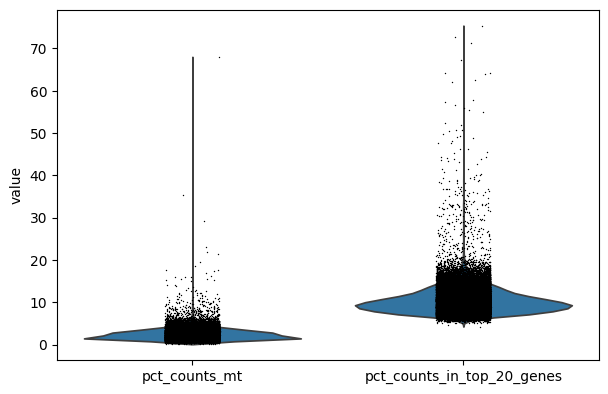

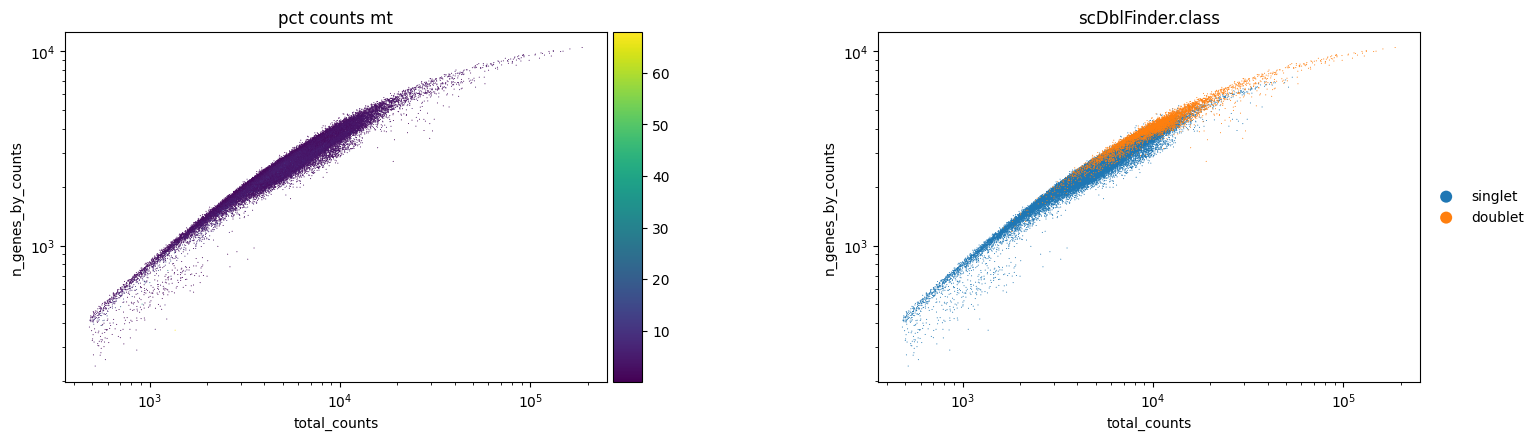

In [4]:
sc.pl.violin(adata, ["pct_counts_mt", "pct_counts_in_top_20_genes"])
axes = sc.pl.scatter(adata, "total_counts", "n_genes_by_counts", color=["pct_counts_mt", "scDblFinder.class"], show=False)
for ax in axes:
    ax.set_xscale("log")
    ax.set_yscale("log")

In [5]:
from scipy.stats import median_abs_deviation

def is_outlier(adata, metric: str, nmads: int, threshold_record: dict | None = None):
    M = adata.obs[metric]
    median = np.median(M)
    MADs = nmads * median_abs_deviation(M)
    if threshold_record is not None:
        threshold_record[metric] = (median - MADs, median + MADs)
    outlier = (M < median - MADs) | (median + MADs < M)
    return outlier

t = dict()
outlier = (
    is_outlier(adata, "log1p_total_counts", 5, t)
    | is_outlier(adata, "log1p_n_genes_by_counts", 5, t) # number of unique genes
    | is_outlier(adata, "pct_counts_in_top_20_genes", 5, t)
    | is_outlier(adata, "pct_counts_mt", 3, t) | (adata.obs["pct_counts_mt"] > 8)
)
adata.obs["is_outlier"] = outlier
outlier.value_counts()

False    49627
True      4820
Name: count, dtype: int64

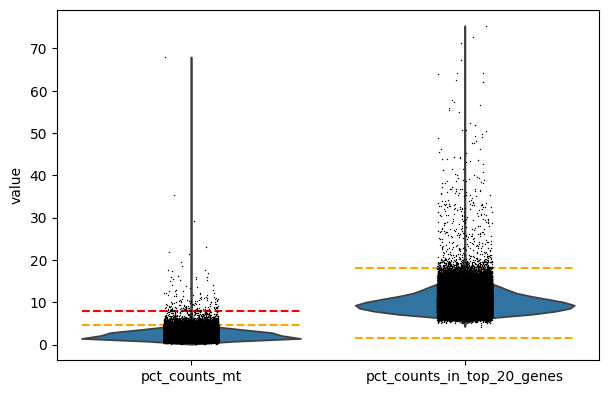

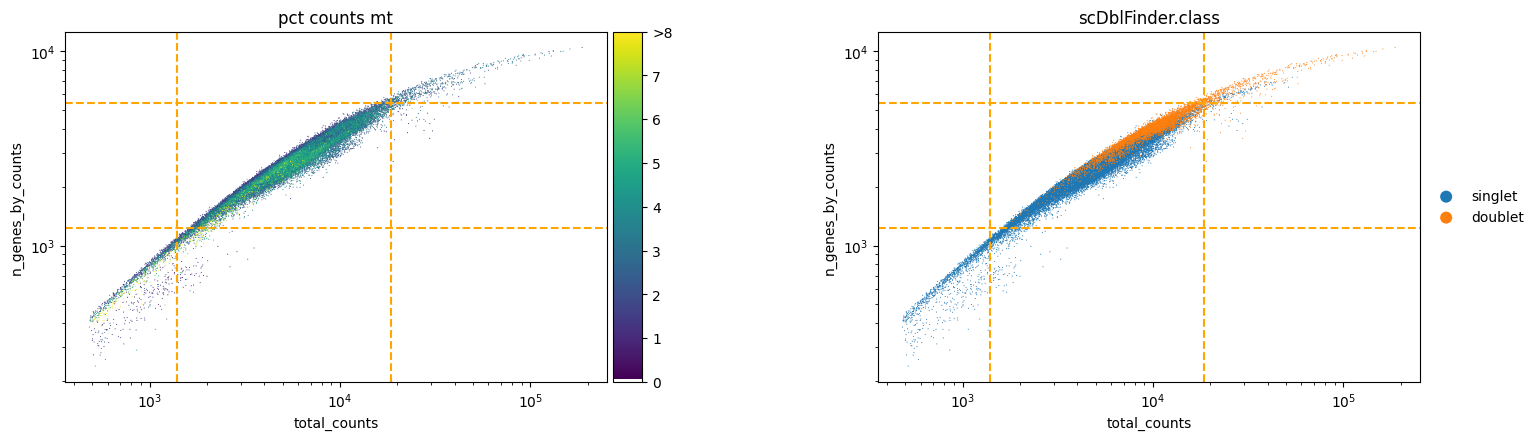

In [ ]:
ax = sc.pl.violin(adata, ["pct_counts_mt", "pct_counts_in_top_20_genes"], show=False)
ax.plot((-0.4, 0.4), [t["pct_counts_mt"][1]]*2, color="orange", ls="--")
ax.plot((-0.4, 0.4), (8, 8), color="red", ls="--")
ax.plot((0.6, 1.4), [t["pct_counts_in_top_20_genes"][0]]*2, color="orange", ls="--")
ax.plot((0.6, 1.4), [t["pct_counts_in_top_20_genes"][1]]*2, color="orange", ls="--")

ax1 = sc.pl.scatter(adata, "total_counts", "n_genes_by_counts", color="pct_counts_mt", show=False)
ax.collections[0].set_clim(vmax=8)
cbar = ax.collections[0].colorbar
assert cbar is not None
ticks = list(cbar.get_ticks())
labels = [str(int(t)) for t in ticks[:-1]] + [f">{int(ticks[-1])}"]
cbar.set_ticks(ticks)
cbar.set_ticklabels(labels)

ax2 = sc.pl.scatter(adata, "total_counts", "n_genes_by_counts", color="scDblFinder.class", show=False)

for ax in [ax1, ax2]:
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.axhline(np.exp(t["log1p_n_genes_by_counts"][0])-1, color="orange", ls="--")
    ax.axhline(np.exp(t["log1p_n_genes_by_counts"][1])-1, color="orange", ls="--")
    ax.axvline(np.exp(t["log1p_total_counts"][0])-1, color="orange", ls="--")
    ax.axvline(np.exp(t["log1p_total_counts"][1])-1, color="orange", ls="--")

In [7]:
display(adata.obs["sample"].value_counts())
display(adata)

singlets = adata.obs['scDblFinder.class'] == "singlet"
print(f"Doublets removed: {(~singlets).sum()}")
adata = adata[singlets, :]
display(adata.obs["sample"].value_counts())
display(adata)

outliers = adata.obs['is_outlier']
print(f"Singlet outliers removed: {(outliers.sum())}")
adata = adata[~outliers, :]
display(adata.obs["sample"].value_counts())
display(adata)

print("\nMin cells filtering for genes: ", end="")
starting_genes = adata.n_vars
sc.pp.filter_genes(adata, min_cells=3) # remove genes found in less than 5 cells
print(f"removed {starting_genes - adata.n_vars} genes")
print(adata.obs["sample"].value_counts())
print(adata)

sample
PBMC_Control1       20490
PBMC_Control2       18232
Lung_Cancer_PBMC    15725
Name: count, dtype: int64

AnnData object with n_obs × n_vars = 54447 × 18129
    obs: 'scDblFinder.cluster', 'scDblFinder.class', 'scDblFinder.score', 'scDblFinder.weighted', 'scDblFinder.difficulty', 'scDblFinder.cxds_score', 'scDblFinder.mostLikelyOrigin', 'scDblFinder.originAmbiguous', 'sample', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'is_outlier'
    var: 'mt', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts'
    uns: 'scDblFinder.class_colors'
    layers: 'counts'

Doublets removed: 5269


sample
PBMC_Control1       18381
PBMC_Control2       16280
Lung_Cancer_PBMC    14517
Name: count, dtype: int64

View of AnnData object with n_obs × n_vars = 49178 × 18129
    obs: 'scDblFinder.cluster', 'scDblFinder.class', 'scDblFinder.score', 'scDblFinder.weighted', 'scDblFinder.difficulty', 'scDblFinder.cxds_score', 'scDblFinder.mostLikelyOrigin', 'scDblFinder.originAmbiguous', 'sample', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'is_outlier'
    var: 'mt', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts'
    uns: 'scDblFinder.class_colors'
    layers: 'counts'

...

sample
PBMC_Control1       17245
PBMC_Control2       14444
Lung_Cancer_PBMC    13367
Name: count, dtype: int64

View of AnnData object with n_obs × n_vars = 45056 × 18129
    obs: 'scDblFinder.cluster', 'scDblFinder.class', 'scDblFinder.score', 'scDblFinder.weighted', 'scDblFinder.difficulty', 'scDblFinder.cxds_score', 'scDblFinder.mostLikelyOrigin', 'scDblFinder.originAmbiguous', 'sample', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'is_outlier'
    var: 'mt', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts'
    uns: 'scDblFinder.class_colors'
    layers: 'counts'


Min cells filtering for genes: 

/Users/nirreiter/miniforge3/envs/single_cell/lib/python3.11/site-packages/scanpy/preprocessing/_simple.py:293: ImplicitModificationWarning: Trying to modify attribute `.var` of view, initializing view as actual.
  adata.var["n_cells"] = number


removed 2512 genes
sample
PBMC_Control1       17245
PBMC_Control2       14444
Lung_Cancer_PBMC    13367
Name: count, dtype: int64
AnnData object with n_obs × n_vars = 45056 × 15617
    obs: 'scDblFinder.cluster', 'scDblFinder.class', 'scDblFinder.score', 'scDblFinder.weighted', 'scDblFinder.difficulty', 'scDblFinder.cxds_score', 'scDblFinder.mostLikelyOrigin', 'scDblFinder.originAmbiguous', 'sample', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'is_outlier'
    var: 'mt', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells'
    uns: 'scDblFinder.class_colors'
    layers: 'counts'


## Normalization

In [ ]:
adata.layers["counts"] = adata.X.copy()
sc.pp.normalize_total(adata)
sc.pp.log1p(adata)
adata.raw = adata

/var/folders/2s/_00dd2vx0blcvkt9x4m4l1th0000gn/T/ipykernel_75153/1668972292.py:1: ImplicitModificationWarning: Setting element `.layers['counts']` of view, initializing view as actual.
  adata.layers["counts"] = adata.X.copy()


## Feature Selection

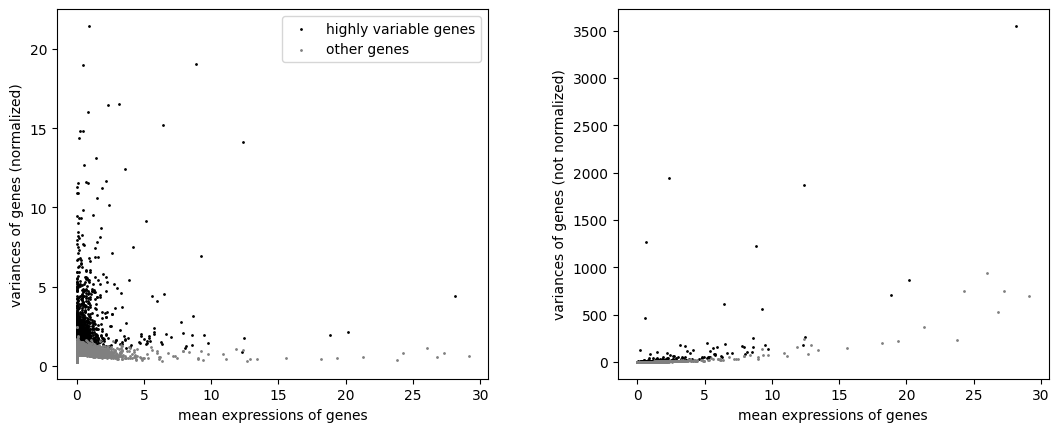

In [8]:
sc.pp.highly_variable_genes(adata, n_top_genes=2000, flavor="seurat_v3", layer="counts", batch_key="sample")
sc.pl.highly_variable_genes(adata)

## PCA

/Users/nirreiter/miniforge3/envs/single_cell/lib/python3.11/site-packages/scanpy/preprocessing/_pca/__init__.py:226: FutureWarning: Argument `use_highly_variable` is deprecated, consider using the mask argument. Use_highly_variable=True can be called through mask_var="highly_variable". Use_highly_variable=False can be called through mask_var=None
  mask_var_param, mask_var = _handle_mask_var(


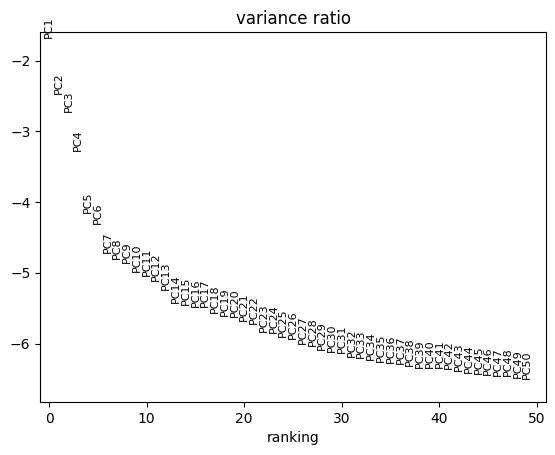

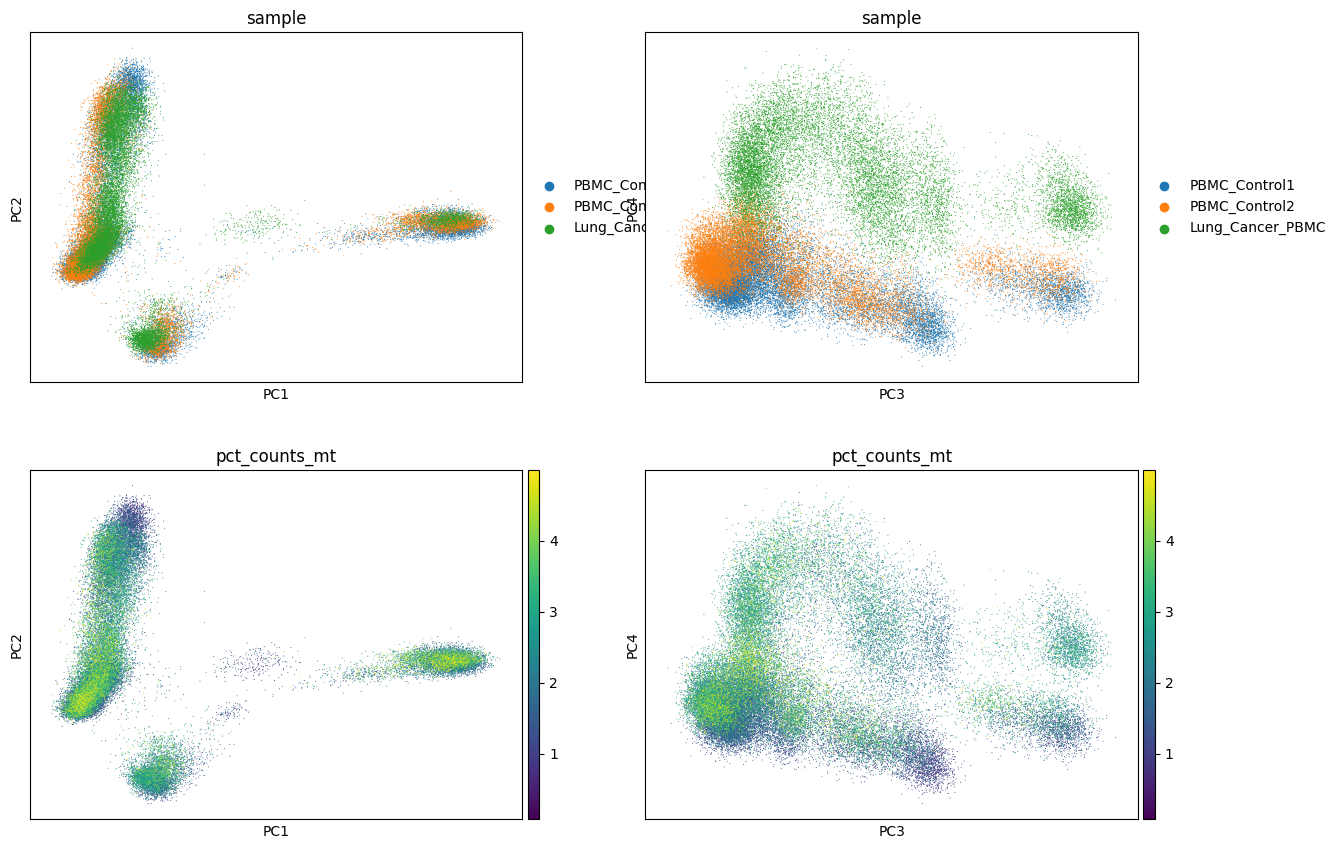

In [9]:
sc.tl.pca(adata, svd_solver="arpack", random_state=SEED, use_highly_variable=True)
sc.pl.pca_variance_ratio(adata, n_pcs=50, log=True)
sc.pl.pca(
    adata,
    color=["sample", "sample", "pct_counts_mt", "pct_counts_mt"],
    dimensions=[(0, 1), (2, 3), (0, 1), (2, 3)],
    ncols=2,
    size=2,
)

## Example UMAP w/o Harmony

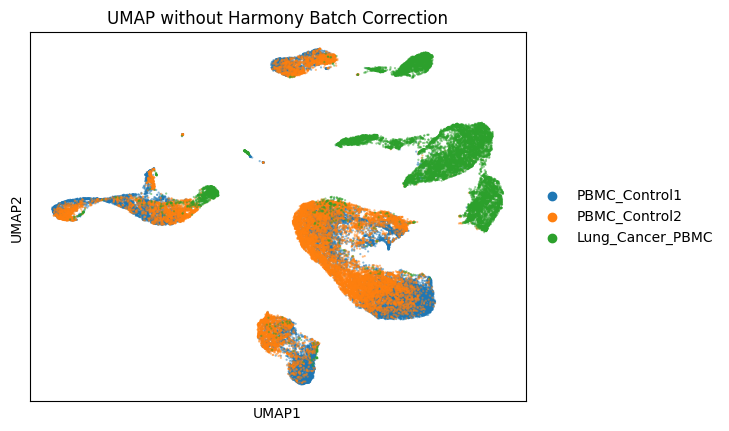

In [10]:
sc.pp.neighbors(
    adata,
    n_neighbors=15,
    n_pcs=6,
    use_rep="X_pca",
    method="umap",
    transformer="sklearn",
    metric="euclidean",
    random_state=SEED,
 )
sc.tl.umap(adata, min_dist=0.1, spread=1.0, random_state=SEED)
sc.pl.umap(adata, color="sample", alpha=0.5, s=10, title="UMAP without Harmony Batch Correction")

## Batch Correction w/ Harmony

In [11]:
pca = np.asarray(adata.obsm["X_pca"], dtype=np.float64)
harmony_out = hm.run_harmony(
    pca,
    adata.obs,
    "sample",
    random_state=SEED,
    ncores=1,
 )
adata.obsm["X_pca_harmony"] = harmony_out.Z_corr

2026-05-13 14:16:35,376 - harmonypy - INFO - Running Harmony
2026-05-13 14:16:35,376 - harmonypy - INFO -   Parameters:
2026-05-13 14:16:35,376 - harmonypy - INFO -     max_iter_harmony: 10
2026-05-13 14:16:35,377 - harmonypy - INFO -     max_iter_kmeans: 4
2026-05-13 14:16:35,377 - harmonypy - INFO -     epsilon_cluster: 0.001
2026-05-13 14:16:35,377 - harmonypy - INFO -     epsilon_harmony: 0.01
2026-05-13 14:16:35,378 - harmonypy - INFO -     nclust: 100
2026-05-13 14:16:35,378 - harmonypy - INFO -     block_size: 0.05
2026-05-13 14:16:35,378 - harmonypy - INFO -     lamb: dynamic (alpha=0.2)
2026-05-13 14:16:35,379 - harmonypy - INFO -     theta: [2. 2. 2.]
2026-05-13 14:16:35,380 - harmonypy - INFO -     sigma: [0.1 0.1 0.1 0.1 0.1]...
2026-05-13 14:16:35,380 - harmonypy - INFO -     verbose: True
2026-05-13 14:16:35,380 - harmonypy - INFO -     random_state: 7
2026-05-13 14:16:35,381 - harmonypy - INFO -   Data: 50 PCs × 47869 cells
2026-05-13 14:16:35,381 - harmonypy - INFO -   

## Neighbors and UMAP

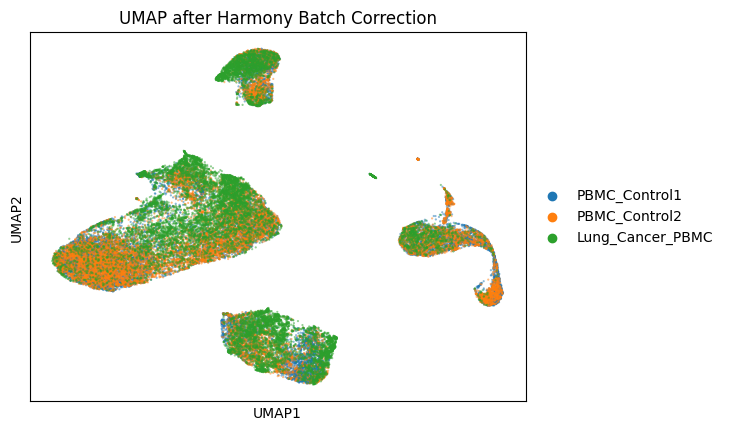

In [12]:
sc.pp.neighbors(
    adata,
    n_neighbors=15,
    n_pcs=6,
    use_rep="X_pca_harmony",
    method="umap",
    transformer="sklearn",
    metric="euclidean",
    random_state=SEED,
 )
sc.tl.umap(adata, min_dist=0.1, spread=1.0, random_state=SEED)
sc.pl.umap(adata, color="sample", alpha=0.5, s=10, title = "UMAP after Harmony Batch Correction")

In [ ]:
adata.write(os.path.join(output_dir, "pp_and_umap_data.h5ad"))